# Baseline XGBoost dla Tuni2025 GPS Spoofing Dataset

Celem notebooka jest przygotowanie klasycznego baseline’u ML do detekcji spoofingu GPS na podstawie cech wyekstrahowanych z surowych plików I/Q.

Pipeline:

1. Wczytanie cech z plików `.parquet`.
2. Audyt scenariuszy i etykiet.
3. Obsługa duplikacji scenariuszy `C5` i `C7`.
4. Korekta etykiet czasowych dla `SS33 delayed spoofing`.
5. Podział train/validation/test bez leakage.
6. Trening modelu XGBoost.
7. Dobór progu decyzyjnego na validation.
8. Ocena końcowa na test set.
9. Analiza per scenariusz oraz feature importance.

## 1. Import bibliotek i konfiguracja środowiska

W tej sekcji importowane są biblioteki potrzebne do:

- przetwarzania danych,
- trenowania modelu XGBoost,
- ewaluacji metryk,
- wizualizacji wyników.

In [58]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)

RANDOM_STATE = 42

ROOT_DIR = Path("/workspace/gps-spoofing")
FEATURES_DIR = ROOT_DIR / "features"
RESULTS_DIR = ROOT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT_DIR:", ROOT_DIR)
print("FEATURES_DIR:", FEATURES_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

ROOT_DIR: /workspace/gps-spoofing
FEATURES_DIR: /workspace/gps-spoofing/features
RESULTS_DIR: /workspace/gps-spoofing/results


## 2. Wczytanie cech z plików Parquet

Każdy plik `.parquet` odpowiada jednemu scenariuszowi GPS spoofing.

Każdy wiersz tabeli reprezentuje jedno okno czasowe sygnału I/Q opisane przez zestaw cech statystycznych i energetycznych.

In [61]:
files = sorted(FEATURES_DIR.glob("*.parquet"))

# Pomijamy pliki techniczne/debugowe
files = [f for f in files if not f.name.startswith("test_")]

print("Number of parquet files:", len(files))

for f in files:
    print(f.name)

Number of parquet files: 9
C5_clean_no_multipath__Clear-Sky_Signal_C-5.parquet
C7_clean_multipath__Clearsky_signal_C-7.parquet
SS17_no_multipath_1_spoofer__SS-17_GPS_Static_No_Multipath_True_Position_-_1_Spoofer.parquet
SS18_no_multipath_2_spoofers__SS-18_GPS_Static_No_Multipath_True_Position_-_2_Spoofers.parquet
SS20_no_multipath_4_spoofers__SS-20_GPS_Static_No_Multipath_True_Position_-_4_Spoofers.parquet
SS27_multipath_1_spoofer__SS-27_GPS_Static_Multipath_True_Position_-_1_Spoofer.parquet
SS28_multipath_2_spoofers__SS-28_GPS_Static_Multipath_True_Position_-_2_Spoofers.parquet
SS29_multipath_4_spoofers__SS-29_GPS_Static_Multipath_True_Position_-_4_Spoofers.parquet
SS33_delayed_all_prns_spoofed__SS-33_GPS_Delayed_Spoofer_Injection_All_PRNs_Spoofed_.parquet


## 3. Budowa wspólnej tabeli danych

Wszystkie pliki `.parquet` są łączone do jednej tabeli `all_df`, która będzie używana do dalszej analizy i podziału danych.

In [62]:
rows = []

for p in files:
    df_part = pd.read_parquet(p)
    rows.append(df_part)

all_df = pd.concat(rows, ignore_index=True)

print("all_df shape:", all_df.shape)

print("\nColumns:")
print(all_df.columns.tolist())

print("\nScenarios:")
print(all_df["scenario"].value_counts())

print("\nOriginal labels:")
print(all_df["label"].value_counts())

all_df shape: (139991, 29)

Columns:
['file', 'scenario', 'window_idx', 'time_s', 'label', 'i_mean', 'q_mean', 'i_std', 'q_std', 'i_abs_mean', 'q_abs_mean', 'iq_corr', 'power_mean', 'power_std', 'power_min', 'power_max', 'power_p50', 'power_p90', 'power_p99', 'amp_mean', 'amp_std', 'amp_min', 'amp_max', 'amp_p50', 'amp_p90', 'amp_p99', 'dc_offset', 'iq_std_ratio', 'papr']

Scenarios:
scenario
SS33_delayed_all_prns_spoofed    19999
C5_clean_no_multipath            14999
C7_clean_multipath               14999
SS17_no_multipath_1_spoofer      14999
SS18_no_multipath_2_spoofers     14999
SS20_no_multipath_4_spoofers     14999
SS27_multipath_1_spoofer         14999
SS28_multipath_2_spoofers        14999
SS29_multipath_4_spoofers        14999
Name: count, dtype: int64

Original labels:
label
1    109993
0     29998
Name: count, dtype: int64


## 4. Audyt scenariuszy i zakresów czasowych

Sprawdzamy:

- liczbę okien w każdym scenariuszu,
- zakres czasu,
- rozkład etykiet.

Jest to konieczne przed podziałem danych i korektą etykiet czasowych.

In [63]:
scenario_summary = (
    all_df
    .groupby("scenario")
    .agg(
        rows=("scenario", "size"),
        label_min=("label", "min"),
        label_max=("label", "max"),
        time_min=("time_s", "min"),
        time_max=("time_s", "max"),
    )
    .reset_index()
)

scenario_summary

,scenario,rows,label_min,label_max,time_min,time_max
0,C5_clean_no_multipath,14999,0,0,0.0,149.98
1,C7_clean_multipath,14999,0,0,0.0,149.98
2,SS17_no_multipath_1_spoofer,14999,1,1,0.0,149.98
3,SS18_no_multipath_2_spoofers,14999,1,1,0.0,149.98
4,SS20_no_multipath_4_spoofers,14999,1,1,0.0,149.98
5,SS27_multipath_1_spoofer,14999,1,1,0.0,149.98
6,SS28_multipath_2_spoofers,14999,1,1,0.0,149.98
7,SS29_multipath_4_spoofers,14999,1,1,0.0,149.98
8,SS33_delayed_all_prns_spoofed,19999,1,1,0.0,199.98


## 5. Weryfikacja duplikacji scenariuszy C5 i C7

W trakcie analizy wykryto, że scenariusze:

- `C5_clean_no_multipath`
- `C7_clean_multipath`

są binarnie identycznymi nagraniami sygnału.

W związku z tym nie mogą być traktowane jako niezależne scenariusze train/test, ponieważ prowadziłoby to do leakage.

W notebooku oba scenariusze traktowane są jako duplikat tego samego clean recording.

In [64]:
C5 = "C5_clean_no_multipath"
C7 = "C7_clean_multipath"

drop_meta_for_hash = [
    "label",
    "file",
    "scenario",
    "window_idx",
    "time_s",
]

feature_cols_for_hash = [
    c for c in all_df.columns
    if c not in drop_meta_for_hash
]

A = (
    all_df[all_df["scenario"] == C5]
    .sort_values("window_idx")[feature_cols_for_hash]
    .reset_index(drop=True)
)

B = (
    all_df[all_df["scenario"] == C7]
    .sort_values("window_idx")[feature_cols_for_hash]
    .reset_index(drop=True)
)

A = A.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(0)
B = B.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(0)

print("Shapes:", A.shape, B.shape)
print("All values exactly equal:", A.equals(B))

if A.shape == B.shape:
    print("Max absolute difference:", np.abs(A.values - B.values).max())

Shapes: (14999, 24) (14999, 24)
All values exactly equal: True
Max absolute difference: 0.0


## 6. Korekta etykiet czasowych dla SS33 delayed spoofing

Scenariusz `SS33_delayed_all_prns_spoofed` nie powinien być oznaczony jako spoof przez cały czas trwania nagrania.

Z dokumentacji scenariusza:

- spoofing startuje około 70 s po rozpoczęciu nagrania,
- aktywny spoofing trwa około 80 s,
- spoofery są usuwane około 150 s.

Dlatego tworzona jest nowa etykieta `label_time`:

- `0` — brak aktywnego spoofingu,
- `1` — aktywny spoofing.

Dodatkowo okna znajdujące się blisko granic czasowych ataku są wykluczane z eksperymentu przez margines niepewności.

In [65]:
df = all_df.copy()

# Zachowujemy oryginalną etykietę plikową
df["label_file"] = df["label"].astype(int)

# Nowa etykieta czasowa
df["label_time"] = df["label_file"].copy()

# Flaga, czy dany wiersz jest używany w eksperymencie
df["use_row"] = True

SS33 = "SS33_delayed_all_prns_spoofed"

attack_start_s = 70.0
attack_end_s = 150.0
margin_s = 2.0

ss33_mask = df["scenario"].eq(SS33)

# Dla SS33 domyślnie ustawiamy clean
df.loc[ss33_mask, "label_time"] = 0

# Aktywna faza spoofingu
ss33_active = (
    ss33_mask
    & (df["time_s"] >= attack_start_s + margin_s)
    & (df["time_s"] <= attack_end_s - margin_s)
)

df.loc[ss33_active, "label_time"] = 1

# Niepewne granice czasowe wykluczamy
ss33_uncertain_start = (
    ss33_mask
    & (df["time_s"] >= attack_start_s - margin_s)
    & (df["time_s"] < attack_start_s + margin_s)
)

ss33_uncertain_end = (
    ss33_mask
    & (df["time_s"] > attack_end_s - margin_s)
    & (df["time_s"] <= attack_end_s + margin_s)
)

df.loc[ss33_uncertain_start | ss33_uncertain_end, "use_row"] = False

ss33_label_check = (
    df[df["scenario"] == SS33]
    .groupby("label_time")["time_s"]
    .agg(["min", "max", "count"])
)

ss33_label_check

,min,max,count
label_time,,,
0,0.0,199.98,12398
1,72.0,148.00,7601


## 7. Filtrowanie danych używanych w eksperymencie

Usuwane są okna oznaczone jako niepewne, znajdujące się blisko momentu aktywacji oraz dezaktywacji spoofingu w scenariuszu SS33.

In [66]:
df_used = df[df["use_row"]].copy()

print("Before filtering:", df.shape)
print("After filtering:", df_used.shape)

print("\nLabels per scenario:")
print(df_used.groupby("scenario")["label_time"].value_counts())

Before filtering: (139991, 32)
After filtering: (139191, 32)

Labels per scenario:
scenario                       label_time
C5_clean_no_multipath          0             14999
C7_clean_multipath             0             14999
SS17_no_multipath_1_spoofer    1             14999
SS18_no_multipath_2_spoofers   1             14999
SS20_no_multipath_4_spoofers   1             14999
SS27_multipath_1_spoofer       1             14999
SS28_multipath_2_spoofers      1             14999
SS29_multipath_4_spoofers      1             14999
SS33_delayed_all_prns_spoofed  0             11598
                               1              7601
Name: count, dtype: int64


## 8. Podział clean recordingów na train/validation/test

Ponieważ `C5` i `C7` są duplikatami tego samego nagrania, oba scenariusze dzielone są według tego samego blokowego splitu czasowego:

- początkowa część → train,
- środkowa część → validation,
- końcowa część → test.

Dodatkowo pomiędzy splitami pozostawiany jest bufor czasowy ograniczający leakage przez sąsiednie okna.

In [67]:
clean_duplicate_scenarios = [
    "C5_clean_no_multipath",
    "C7_clean_multipath",
]

clean_df = df_used[df_used["scenario"].isin(clean_duplicate_scenarios)].copy()
clean_df = clean_df.sort_values(["scenario", "time_s"]).reset_index(drop=True)

t_min = clean_df["time_s"].min()
t_max = clean_df["time_s"].max()
duration = t_max - t_min

gap_s = 5.0

train_end = t_min + 0.60 * duration
val_start = train_end + gap_s
val_end = t_min + 0.75 * duration
test_start = val_end + gap_s

clean_train_df = clean_df[clean_df["time_s"] < train_end].copy()

clean_val_df = clean_df[
    (clean_df["time_s"] > val_start)
    & (clean_df["time_s"] < val_end)
].copy()

clean_test_df = clean_df[clean_df["time_s"] > test_start].copy()

print("Clean train:", clean_train_df.shape)
print("Clean val:", clean_val_df.shape)
print("Clean test:", clean_test_df.shape)

print("\nClean train scenarios:")
print(clean_train_df["scenario"].value_counts())

print("\nClean val scenarios:")
print(clean_val_df["scenario"].value_counts())

print("\nClean test scenarios:")
print(clean_test_df["scenario"].value_counts())

print("\nTime ranges:")
print("train:", clean_train_df["time_s"].min(), clean_train_df["time_s"].max())
print("val:", clean_val_df["time_s"].min(), clean_val_df["time_s"].max())
print("test:", clean_test_df["time_s"].min(), clean_test_df["time_s"].max())

Clean train: (17998, 32)
Clean val: (3500, 32)
Clean test: (6500, 32)

Clean train scenarios:
scenario
C5_clean_no_multipath    8999
C7_clean_multipath       8999
Name: count, dtype: int64

Clean val scenarios:
scenario
C5_clean_no_multipath    1750
C7_clean_multipath       1750
Name: count, dtype: int64

Clean test scenarios:
scenario
C5_clean_no_multipath    3250
C7_clean_multipath       3250
Name: count, dtype: int64

Time ranges:
train: 0.0 89.98
val: 94.99 112.48
test: 117.49 149.98


## 9. Podział scenariuszy spoofingowych

Scenariusze spoofingowe dzielone są po całych scenariuszach, aby uniknąć mieszania okien z tego samego ataku pomiędzy train, validation i test.

Scenariusz `SS33` pozostaje wyłącznie w test set i korzysta z etykiet czasowych `label_time`.

In [69]:
train_attack_scenarios = [
    "SS17_no_multipath_1_spoofer",
    "SS18_no_multipath_2_spoofers",
    "SS20_no_multipath_4_spoofers",
    "SS27_multipath_1_spoofer",
]

val_attack_scenarios = [
    "SS28_multipath_2_spoofers",
]

test_attack_scenarios = [
    "SS29_multipath_4_spoofers",
    "SS33_delayed_all_prns_spoofed",
]

attack_train_df = df_used[df_used["scenario"].isin(train_attack_scenarios)].copy()
attack_val_df = df_used[df_used["scenario"].isin(val_attack_scenarios)].copy()
attack_test_df = df_used[df_used["scenario"].isin(test_attack_scenarios)].copy()

train_df = pd.concat([clean_train_df, attack_train_df], ignore_index=True)
val_df = pd.concat([clean_val_df, attack_val_df], ignore_index=True)
test_df = pd.concat([clean_test_df, attack_test_df], ignore_index=True)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df["label_time"].value_counts())

print("\nVal labels:")
print(val_df["label_time"].value_counts())

print("\nTest labels:")
print(test_df["label_time"].value_counts())

print("\nTest labels per scenario:")
print(test_df.groupby("scenario")["label_time"].value_counts())

Train: (77994, 32)
Val: (18499, 32)
Test: (40698, 32)

Train labels:
label_time
1    59996
0    17998
Name: count, dtype: int64

Val labels:
label_time
1    14999
0     3500
Name: count, dtype: int64

Test labels:
label_time
1    22600
0    18098
Name: count, dtype: int64

Test labels per scenario:
scenario                       label_time
C5_clean_no_multipath          0              3250
C7_clean_multipath             0              3250
SS29_multipath_4_spoofers      1             14999
SS33_delayed_all_prns_spoofed  0             11598
                               1              7601
Name: count, dtype: int64


## 10. Przygotowanie macierzy cech i etykiet

Do modelu przekazywane są wyłącznie cechy sygnałowe.

Usuwane są kolumny techniczne oraz metadane:

- etykiety,
- nazwy plików,
- nazwy scenariuszy,
- indeksy okien,
- znaczniki czasu.

In [70]:
drop_cols = [
    "label",
    "label_file",
    "label_time",
    "use_row",
    "file",
    "scenario",
    "window_idx",
    "time_s",
]

X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
y_train = train_df["label_time"].astype(int)

X_val = val_df.drop(columns=[c for c in drop_cols if c in val_df.columns])
y_val = val_df["label_time"].astype(int)

X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
y_test = test_df["label_time"].astype(int)

# Tylko kolumny numeryczne
X_train = X_train.select_dtypes(include=[np.number])
X_val = X_val[X_train.columns]
X_test = X_test[X_train.columns]

# Czyszczenie NaN/inf
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_val = X_val.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nFeatures used by model:")
print(X_train.columns.tolist())

print("\nForbidden columns check:")
for c in drop_cols:
    print(c, c in X_train.columns)

X_train: (77994, 24)
X_val: (18499, 24)
X_test: (40698, 24)

Features used by model:
['i_mean', 'q_mean', 'i_std', 'q_std', 'i_abs_mean', 'q_abs_mean', 'iq_corr', 'power_mean', 'power_std', 'power_min', 'power_max', 'power_p50', 'power_p90', 'power_p99', 'amp_mean', 'amp_std', 'amp_min', 'amp_max', 'amp_p50', 'amp_p90', 'amp_p99', 'dc_offset', 'iq_std_ratio', 'papr']

Forbidden columns check:
label False
label_file False
label_time False
use_row False
file False
scenario False
window_idx False
time_s False


## 11. Kontrola leakage pomiędzy train, validation i test

Sprawdzamy, czy identyczne wiersze cech nie występują jednocześnie w różnych splitach danych.

Jest to szczególnie ważne ze względu na duplikację scenariuszy `C5` i `C7`.

In [71]:
def hash_X(X):
    return set(pd.util.hash_pandas_object(X.reset_index(drop=True), index=False))

train_hash = hash_X(X_train)
val_hash = hash_X(X_val)
test_hash = hash_X(X_test)

train_val_overlap = len(train_hash & val_hash)
train_test_overlap = len(train_hash & test_hash)
val_test_overlap = len(val_hash & test_hash)

print("train-val overlap:", train_val_overlap)
print("train-test overlap:", train_test_overlap)
print("val-test overlap:", val_test_overlap)

assert train_val_overlap == 0
assert train_test_overlap == 0
assert val_test_overlap == 0

train-val overlap: 0
train-test overlap: 0
val-test overlap: 0


## 12. Trening modelu XGBoost

Trenowany jest regularizowany model XGBoost działający na cechach statystycznych i energetycznych sygnału GPS.

Validation set służy do monitorowania procesu uczenia oraz późniejszego doboru progu decyzyjnego.

In [72]:
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())

scale_pos_weight = neg / pos

print("neg:", neg)
print("pos:", pos)
print("scale_pos_weight:", scale_pos_weight)

model = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.01,

    max_depth=3,
    min_child_weight=5,
    gamma=0.05,

    subsample=0.75,
    colsample_bytree=0.75,

    reg_lambda=10.0,
    reg_alpha=0.1,

    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",

    scale_pos_weight=scale_pos_weight,

    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

neg: 17998
pos: 59996
scale_pos_weight: 0.29998666577771854
[0]	validation_0-logloss:0.68323
[100]	validation_0-logloss:0.20132
[200]	validation_0-logloss:0.06995
[300]	validation_0-logloss:0.02566
[400]	validation_0-logloss:0.00982
[500]	validation_0-logloss:0.00402
[600]	validation_0-logloss:0.00184
[700]	validation_0-logloss:0.00097
[800]	validation_0-logloss:0.00059
[900]	validation_0-logloss:0.00040
[1000]	validation_0-logloss:0.00037
[1100]	validation_0-logloss:0.00037
[1199]	validation_0-logloss:0.00037


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.75
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## 13. Ewaluacja validation set dla domyślnego progu 0.5

Na tym etapie sprawdzane są podstawowe metryki modelu:

- confusion matrix,
- precision,
- recall,
- F1-score,
- ROC-AUC,
- PR-AUC.

In [73]:
y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred_05 = (y_val_proba >= 0.5).astype(int)

print("VALIDATION @ threshold 0.5")
print(confusion_matrix(y_val, y_val_pred_05, labels=[0, 1]))

print(classification_report(
    y_val,
    y_val_pred_05,
    labels=[0, 1],
    target_names=["clean", "spoof"],
    zero_division=0,
))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("PR-AUC:", average_precision_score(y_val, y_val_proba))

VALIDATION @ threshold 0.5
[[ 3500     0]
 [    0 14999]]
              precision    recall  f1-score   support

       clean       1.00      1.00      1.00      3500
       spoof       1.00      1.00      1.00     14999

    accuracy                           1.00     18499
   macro avg       1.00      1.00      1.00     18499
weighted avg       1.00      1.00      1.00     18499

ROC-AUC: 1.0
PR-AUC: 1.0


## 14. Dobór progu decyzyjnego

Model zwraca prawdopodobieństwo klasy spoof.

Próg klasyfikacji dobierany jest na validation set tak, aby:

- ograniczyć FPR,
- jednocześnie minimalizować FNR.

W detekcji spoofingu szczególnie istotne jest ograniczenie false negatives, czyli przypadków, gdy aktywny spoofing zostaje uznany za clean.

In [74]:
thresholds = np.concatenate([
    np.logspace(-6, -2, 50),
    np.linspace(0.01, 0.99, 99),
])

rows = []

for thr in thresholds:
    pred = (y_val_proba >= thr).astype(int)
    cm = confusion_matrix(y_val, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    recall_spoof = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision_spoof = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    rows.append({
        "threshold": thr,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "FPR": fpr,
        "FNR": fnr,
        "recall_spoof": recall_spoof,
        "precision_spoof": precision_spoof,
    })

thr_df = pd.DataFrame(rows)

MAX_FPR = 0.01
candidates = thr_df[thr_df["FPR"] <= MAX_FPR].copy()

if len(candidates) > 0:
    best_row = candidates.sort_values(
        ["FNR", "threshold"],
        ascending=[True, False],
    ).iloc[0]
else:
    best_row = thr_df.sort_values(
        ["FNR", "FPR"],
        ascending=[True, True],
    ).iloc[0]

BEST_THRESHOLD = float(best_row["threshold"])

print("BEST_THRESHOLD:", BEST_THRESHOLD)
best_row

BEST_THRESHOLD: 0.99


threshold              0.99
TN                  3500.00
FP                     0.00
FN                     0.00
TP                 14999.00
FPR                    0.00
FNR                    0.00
recall_spoof           1.00
precision_spoof        1.00
Name: 148, dtype: float64

## 15. Finalna ewaluacja na test set

Test set nie był używany podczas treningu ani strojenia thresholda.

Raportowane są:

- confusion matrix,
- precision,
- recall,
- F1-score,
- ROC-AUC,
- PR-AUC.

In [75]:
y_test_proba = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= BEST_THRESHOLD).astype(int)

print("TEST @ BEST_THRESHOLD =", BEST_THRESHOLD)
print(confusion_matrix(y_test, y_test_pred, labels=[0, 1]))

print(classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=["clean", "spoof"],
    zero_division=0,
))

print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print("PR-AUC:", average_precision_score(y_test, y_test_proba))

TEST @ BEST_THRESHOLD = 0.99
[[17399   699]
 [   48 22552]]
              precision    recall  f1-score   support

       clean       1.00      0.96      0.98     18098
       spoof       0.97      1.00      0.98     22600

    accuracy                           0.98     40698
   macro avg       0.98      0.98      0.98     40698
weighted avg       0.98      0.98      0.98     40698

ROC-AUC: 0.9806451306896474
PR-AUC: 0.9699348006427292


## 16. Jawne obliczenie FPR, FNR i attack recall

Dla systemów detekcji spoofingu szczególnie ważne są:

- FPR — false positive rate,
- FNR — false negative rate,
- attack recall — skuteczność wykrywania spoofingu.

In [76]:
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
attack_recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
clean_recall = tn / (tn + fp) if (tn + fp) > 0 else np.nan

global_results = pd.DataFrame([{
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "FPR": fpr,
    "FNR": fnr,
    "clean_recall": clean_recall,
    "attack_recall": attack_recall,
    "ROC_AUC": roc_auc_score(y_test, y_test_proba),
    "PR_AUC": average_precision_score(y_test, y_test_proba),
    "threshold": BEST_THRESHOLD,
}])

global_results

,TN,FP,FN,TP,FPR,FNR,clean_recall,attack_recall,ROC_AUC,PR_AUC,threshold
0,17399,699,48,22552,0.038623,0.002124,0.961377,0.997876,0.980645,0.969935,0.99


## 17. Wyniki per scenariusz

Globalne metryki mogą maskować problemy występujące tylko w wybranych scenariuszach.

Dlatego wyniki raportowane są również osobno dla każdego scenariusza testowego.

In [77]:
test_eval_df = test_df.copy()
test_eval_df["proba_spoof"] = y_test_proba
test_eval_df["pred"] = y_test_pred

scenario_rows = []

for scenario in sorted(test_eval_df["scenario"].unique()):
    tmp = test_eval_df[test_eval_df["scenario"] == scenario].copy()

    y_true_s = tmp["label_time"].astype(int)
    y_pred_s = tmp["pred"].astype(int)

    cm_s = confusion_matrix(y_true_s, y_pred_s, labels=[0, 1])
    tn, fp, fn, tp = cm_s.ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    recall_spoof = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    recall_clean = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    scenario_rows.append({
        "scenario": scenario,
        "n": len(tmp),
        "true_clean": int((y_true_s == 0).sum()),
        "true_spoof": int((y_true_s == 1).sum()),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "FPR": fpr,
        "FNR": fnr,
        "clean_recall": recall_clean,
        "spoof_recall": recall_spoof,
        "mean_proba_spoof": tmp["proba_spoof"].mean(),
        "min_proba_spoof": tmp["proba_spoof"].min(),
        "max_proba_spoof": tmp["proba_spoof"].max(),
    })

scenario_results_df = pd.DataFrame(scenario_rows)
scenario_results_df

,scenario,n,true_clean,true_spoof,TN,FP,FN,TP,FPR,FNR,clean_recall,spoof_recall,mean_proba_spoof,min_proba_spoof,max_proba_spoof
0,C5_clean_no_multipath,3250,3250,0,3250,0,0,0,0.000000,NaN,1.000000,NaN,0.000367,0.000367,0.000367
1,C7_clean_multipath,3250,3250,0,3250,0,0,0,0.000000,NaN,1.000000,NaN,0.000367,0.000367,0.000367
2,SS29_multipath_4_spoofers,14999,0,14999,0,0,0,14999,NaN,0.000000,NaN,1.000000,0.999633,0.999625,0.999633
3,SS33_delayed_all_prns_spoofed,19199,11598,7601,10899,699,48,7553,0.060269,0.006315,0.939731,0.993685,0.429949,0.000367,0.999633


## 18. Analiza czasowa scenariusza SS33 delayed spoofing

Dla scenariusza `SS33` analizowany jest przebieg prawdopodobieństwa spoofingu w funkcji czasu.

Model powinien:

- dawać niskie prawdopodobieństwo przed aktywacją spoofingu,
- wysokie prawdopodobieństwo podczas aktywnej fazy ataku,
- ponownie niskie prawdopodobieństwo po usunięciu spoofingu.

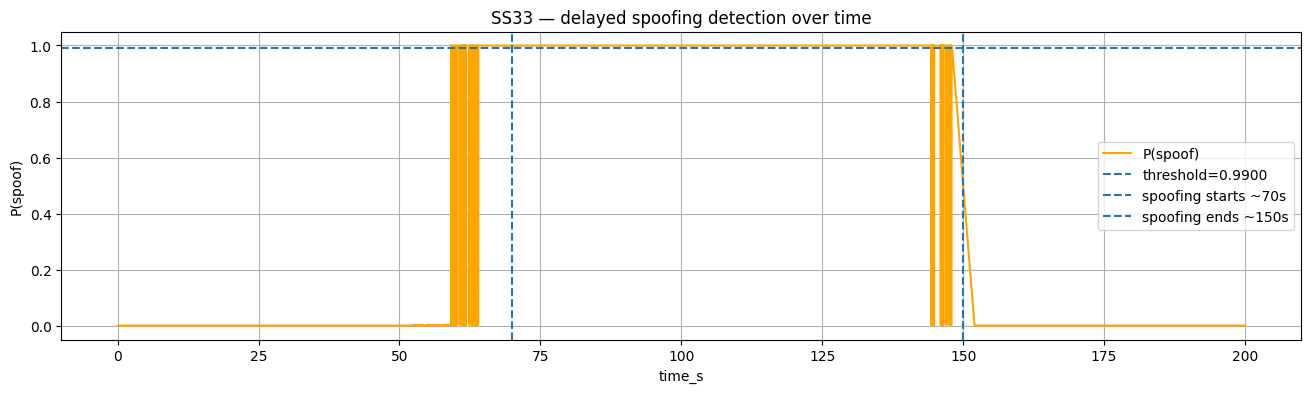

In [79]:
ss33 = test_eval_df[test_eval_df["scenario"] == SS33].copy()
ss33 = ss33.sort_values("time_s")

plt.figure(figsize=(16, 4))
plt.plot(ss33["time_s"], ss33["proba_spoof"], label="P(spoof)",color="orange")
plt.axhline(BEST_THRESHOLD, linestyle="--", label=f"threshold={BEST_THRESHOLD:.4f}")

plt.axvline(attack_start_s, linestyle="--", label="spoofing starts ~70s")
plt.axvline(attack_end_s, linestyle="--", label="spoofing ends ~150s")

plt.title("SS33 — delayed spoofing detection over time")
plt.xlabel("time_s")
plt.ylabel("P(spoof)")
plt.grid(True)
plt.legend()
plt.show()

## 19. Analiza ważności cech

Sprawdzamy, które cechy miały największy wpływ na decyzje modelu XGBoost.

Interpretacja feature importance wymaga ostrożności — wysokie znaczenie cech mocy/amplitudy może oznaczać, że model wykorzystuje różnice energetyczne pomiędzy scenariuszami.

In [80]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

importance_df.head(30)

,feature,importance
5,q_abs_mean,0.233617
8,power_std,0.188926
11,power_p50,0.129804
14,amp_mean,0.112478
2,i_std,0.109693
18,amp_p50,0.105092
4,i_abs_mean,0.053599
3,q_std,0.033883
15,amp_std,0.019116
7,power_mean,0.012987


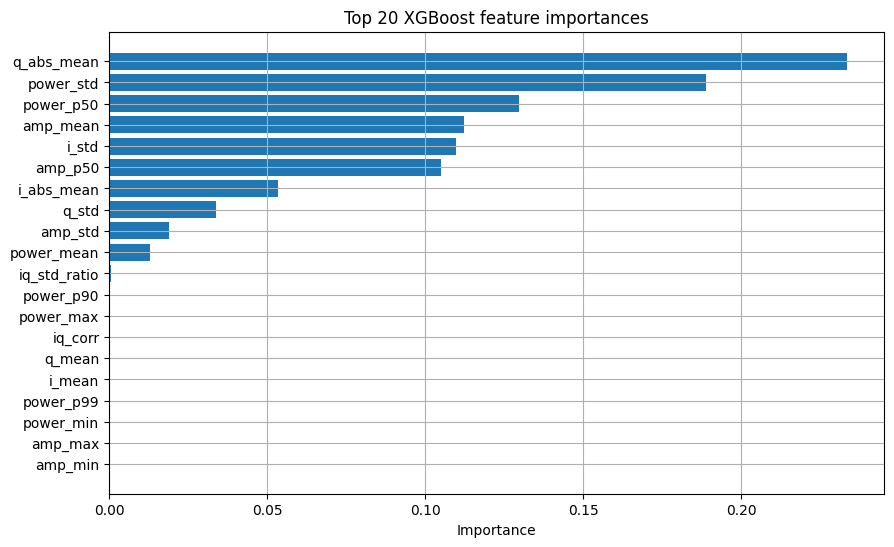

In [81]:
top = importance_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 20 XGBoost feature importances")
plt.grid(True)
plt.show()

## 20. Rozkłady najważniejszych cech

Analizujemy rozkłady cech o najwyższym feature importance dla klas:

- clean,
- spoof.

Pozwala to ocenić, czy model nie separuje klas w trywialny sposób, np. wyłącznie na podstawie poziomu mocy sygnału.

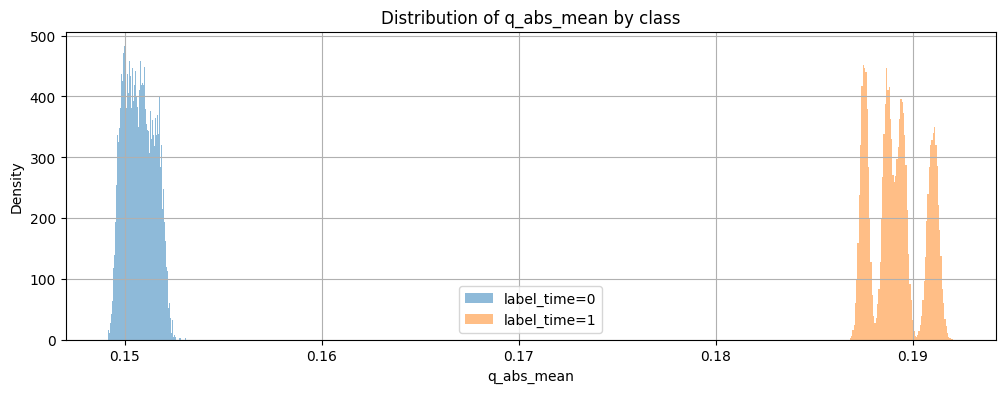

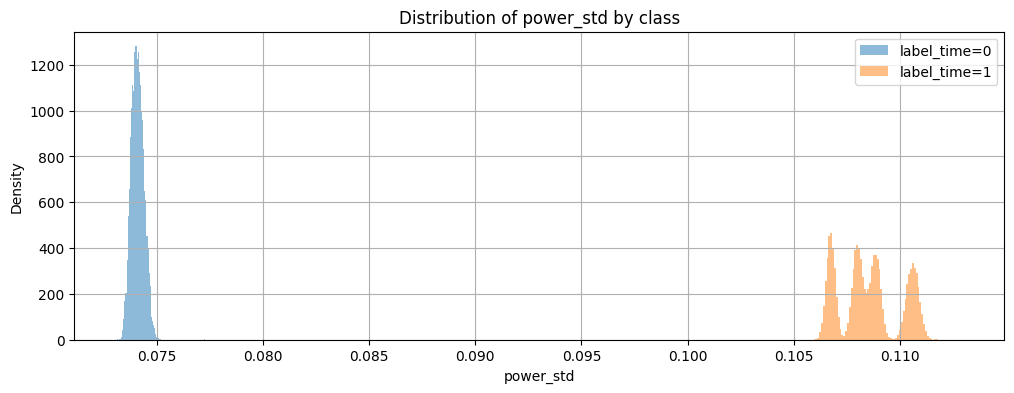

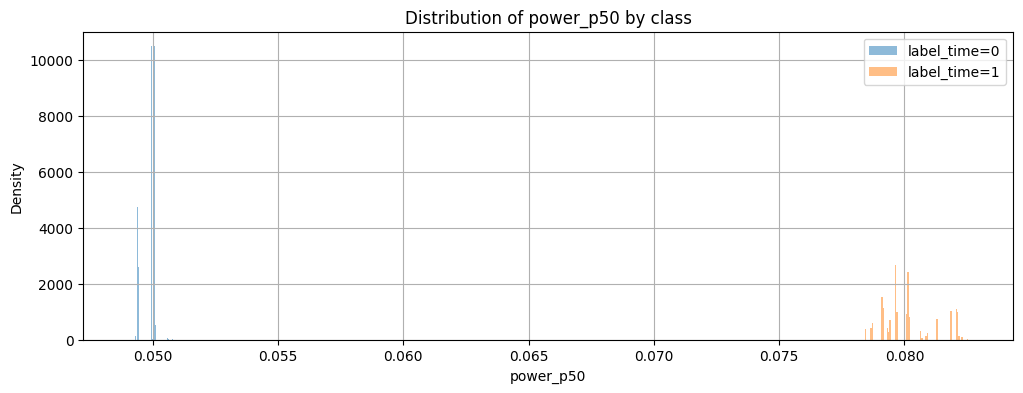

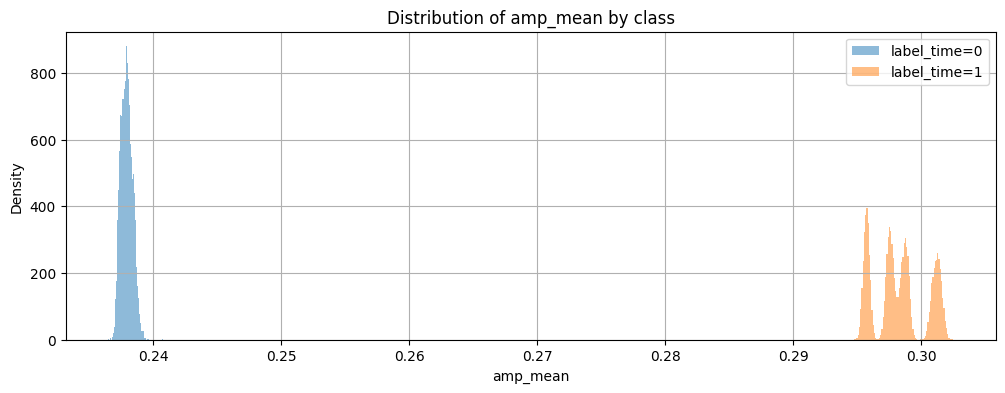

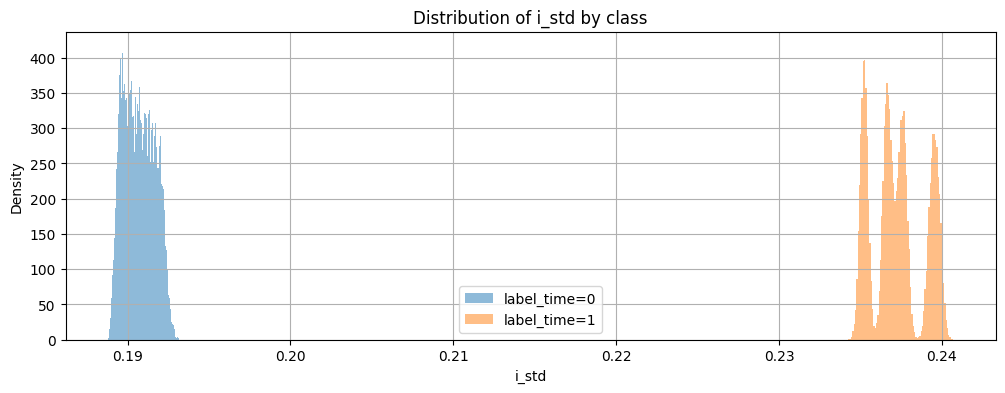

In [83]:
top_features = importance_df.head(5)["feature"].tolist()

plot_df = train_df.copy()

for feature in top_features:
    plt.figure(figsize=(12, 4))

    for label_value in [0, 1]:
        tmp = plot_df[plot_df["label_time"] == label_value]
        plt.hist(
            tmp[feature],
            bins=80,
            alpha=0.5,
            density=True,
            label=f"label_time={label_value}",
        )

    plt.title(f"Distribution of {feature} by class")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.grid(True)
    plt.legend()
    plt.show()

## 21. Zapis wyników eksperymentu

Zapisywane są:

- globalne metryki,
- wyniki per scenariusz,
- feature importance,
- wyniki strojenia thresholda,
- predykcje testowe.

In [84]:
global_results.to_csv(RESULTS_DIR / "xgboost_global_results.csv", index=False)
scenario_results_df.to_csv(RESULTS_DIR / "xgboost_scenario_results.csv", index=False)
importance_df.to_csv(RESULTS_DIR / "xgboost_feature_importance.csv", index=False)
thr_df.to_csv(RESULTS_DIR / "xgboost_threshold_search.csv", index=False)
test_eval_df.to_csv(RESULTS_DIR / "xgboost_test_predictions.csv", index=False)

print("Saved results to:", RESULTS_DIR)

Saved results to: /workspace/gps-spoofing/results


## 22. Podsumowanie

W części XGBoost przygotowano klasyczny baseline ML do detekcji spoofingu GPS na podstawie cech statystycznych i energetycznych wyekstrahowanych z sygnału I/Q.

Najważniejsze decyzje metodologiczne:

1. Model trenowany był na cechach zapisanych w plikach `.parquet`, a nie bezpośrednio na surowych próbkach I/Q.
2. Podział danych wykonano po scenariuszach spoofingowych, aby ograniczyć leakage.
3. Wykryto, że `C5` i `C7` są duplikatami tego samego clean recording.
4. Dla scenariusza `SS33 delayed spoofing` zastosowano etykiety czasowe zależne od aktywnej fazy spoofingu.
5. Próg decyzyjny dobrano na validation set przy ograniczeniu FPR.
6. Finalna ewaluacja została wykonana na niewidzianym test set.

Ograniczenia:

- dostępny jest tylko jeden unikalny clean recording,
- część scenariuszy nadal korzysta z etykiet plikowych,
- obecny zestaw cech jest głównie statystyczno-energetyczny,
- dalsza poprawa może wymagać cech widmowych lub modeli działających bezpośrednio na I/Q.